In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from sklearn.ensemble import IsolationForest, AdaBoostClassifier
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, truncnorm
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report


# Load processed dataset

In [32]:
X_train = pd.read_csv('FIFA_Binary_Cleaned_Final_Train.csv')
X_test = pd.read_csv('FIFA_Binary_Cleaned_Final_Test.csv')

In [33]:
target_column = 'overall_binary' 

y_train = X_train[target_column]
X_train = X_train.drop(columns=[target_column])

y_test = X_test[target_column]
X_test = X_test.drop(columns=[target_column])

# Anomaly Detection methods

In [34]:
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train)
X_train_pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])

In [35]:
iso = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso.fit_predict(X_train_pca_df)
iso_anoms = (iso_preds == -1)

In [36]:
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_train_pca_df)
dist, _ = knn.kneighbors(X_train_pca_df)
knn_thresh = np.percentile(dist[:, -1], 95) # 5% outliers
knn_anoms = dist[:, -1] > knn_thresh

In [37]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_anoms = (lof.fit_predict(X_train_pca_df) == -1)

In [38]:
total_anomalies = iso_anoms.astype(int) + knn_anoms.astype(int) + lof_anoms.astype(int)

In [39]:
mask = total_anomalies < 2
X_train_refined = X_train[mask].reset_index(drop=True)
y_train_refined = y_train[mask].reset_index(drop=True)
print(f"Original rows: {len(X_train)} | Refined rows: {len(X_train_refined)}")

Original rows: 14622 | Refined rows: 13990


# Visualising Anomalies

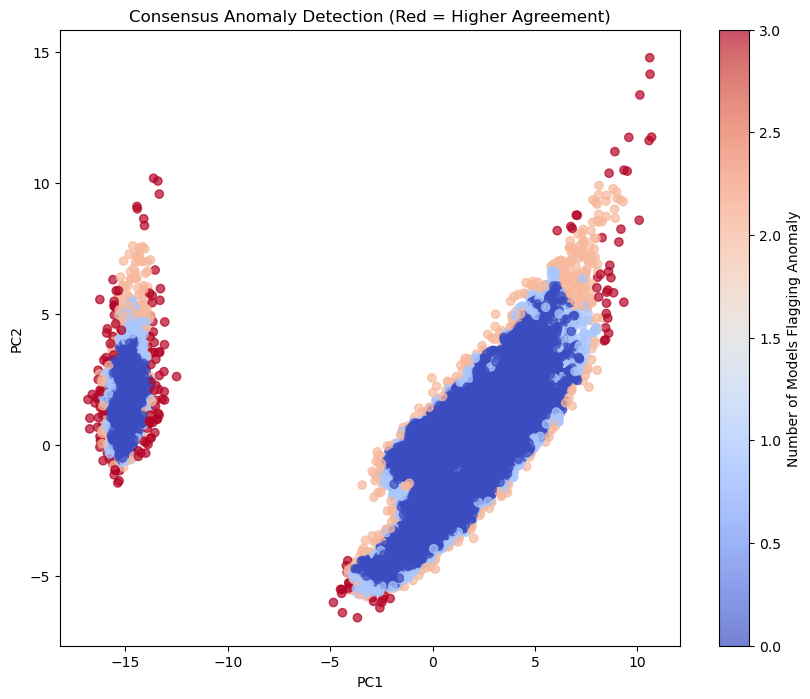

✅ Original Train Size: 14622
✅ Refined Train Size: 13990
✅ Points Removed: 632


In [40]:
plt.figure(figsize=(10, 8))
plt.scatter(X_train_pca_df.iloc[:, 0], X_train_pca_df.iloc[:, 1], 
            c=total_anomalies, cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Number of Models Flagging Anomaly')
plt.title('Consensus Anomaly Detection (Red = Higher Agreement)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

print(f"✅ Original Train Size: {len(X_train)}")
print(f"✅ Refined Train Size: {len(X_train_refined)}")
print(f"✅ Points Removed: {len(X_train) - len(X_train_refined)}")

# Recursive Feature Elimination (RFE)

In [41]:

X_train_iter = X_train_refined.copy()
X_test_iter = X_test.copy()
remaining_features = X_train_iter.columns.tolist()

best_accuracy = 0
best_features_list = []
history = []

print(f"{'Features':<10} | {'Accuracy':<10} | {'Removed Feature'}")
print("-" * 45)

while len(remaining_features) > 1:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=50,
        random_state=42
    )
    
    model.fit(X_train_iter, y_train_refined)
    
    y_pred = model.predict(X_test_iter)
    acc = accuracy_score(y_test, y_pred)
    
    history.append((len(remaining_features), acc))
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_features_list = remaining_features.copy()

    importances = model.feature_importances_
    least_important_idx = np.argmin(importances)
    removed_feature = remaining_features[least_important_idx]
    
    print(f"{len(remaining_features):<10} | {acc:<10.4f} | {removed_feature}")
    
    remaining_features.remove(removed_feature)
    X_train_iter = X_train_iter[remaining_features]
    X_test_iter = X_test_iter[remaining_features]

print(f"\n✅ Optimization Finished!")
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Final Feature Count: {len(best_features_list)}")

Features   | Accuracy   | Removed Feature
---------------------------------------------
74         | 0.9806     | international_reputation
73         | 0.9806     | skill_moves
72         | 0.9806     | num_positions
71         | 0.9806     | gk_speed
70         | 0.9806     | player_tags_count
69         | 0.9806     | nation_position
68         | 0.9806     | gk_kicking
67         | 0.9806     | joined_year
66         | 0.9806     | nation_jersey_number
65         | 0.9762     | preferred_foot_Right
64         | 0.9781     | weak_foot
63         | 0.9781     | pace
62         | 0.9800     | joined_month
61         | 0.9803     | real_face_Yes
60         | 0.9770     | body_type
59         | 0.9795     | player_traits_count
58         | 0.9784     | work_rate
57         | 0.9795     | gk_positioning
56         | 0.9792     | contract_valid_until
55         | 0.9754     | gk_handling
54         | 0.9754     | dribbling
53         | 0.9776     | passing
52         | 0.9759     | defendi

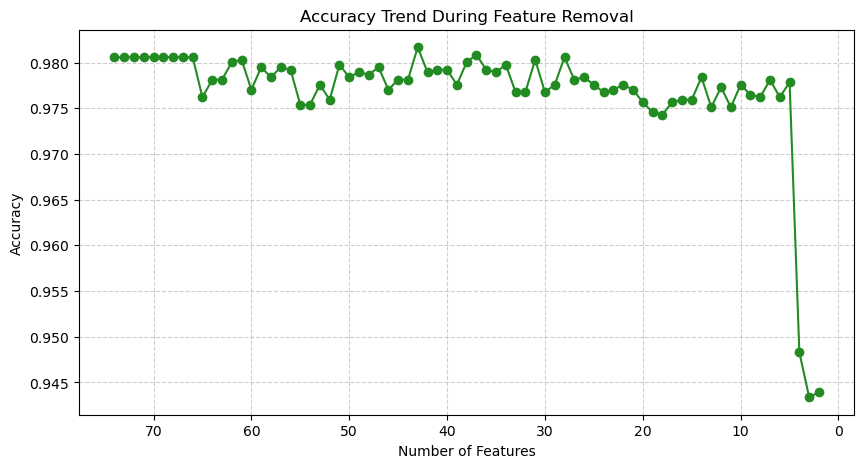

In [42]:
hist_df = pd.DataFrame(history, columns=['n_features', 'accuracy'])
plt.figure(figsize=(10, 5))
plt.plot(hist_df['n_features'], hist_df['accuracy'], marker='o', color='forestgreen')
plt.title('Accuracy Trend During Feature Removal')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.gca().invert_xaxis() 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Model comparaison before anomaly detection and after

In [43]:

baseline_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=12, random_state=42),
    n_estimators=50, random_state=42
)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred_baseline)

accuracy_after = best_accuracy

print("\n" + "="*50)
print("             MODEL PERFORMANCE RESULTS")
print("="*50)
print(f"The Model accuracy before anomaly detection: {accuracy_before:.16f}")
print(f"After Removal of anomalies: {accuracy_after:.4f}")
print("="*50)

print(f"Optimal Number of Features: {len(history)}")
print(f"Improvement Gain: {((accuracy_after - accuracy_before) / accuracy_before) * 100:.2f}%")


             MODEL PERFORMANCE RESULTS
The Model accuracy before anomaly detection: 0.9811269146608315
After Removal of anomalies: 0.9817
Optimal Number of Features: 73
Improvement Gain: 0.06%


# Confusion matrix

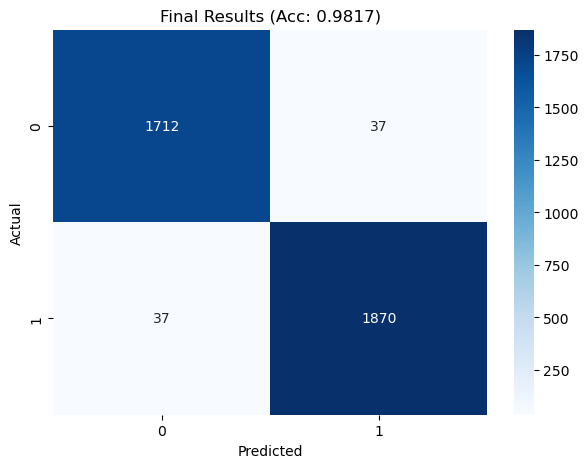


Final Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1749
           1       0.98      0.98      0.98      1907

    accuracy                           0.98      3656
   macro avg       0.98      0.98      0.98      3656
weighted avg       0.98      0.98      0.98      3656



In [44]:
final_model = AdaBoostClassifier(random_state=42)
final_model.fit(X_train_refined[best_features_list], y_train_refined)
final_preds = final_model.predict(X_test[best_features_list])

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues')
plt.title(f"Final Results (Acc: {best_accuracy:.4f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nFinal Classification Report:")
print(classification_report(y_test, final_preds))

# Model comparaison on refined dataset to identify better accurcy

In [45]:
models = {
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=100,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        max_depth=15, 
        random_state=42
    )
}

results = []

print("--- Model Performance Comparison ---")

for name, model in models.items():
    model.fit(X_train_refined[best_features_list], y_train_refined)
    
    y_pred = model.predict(X_test[best_features_list])
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })
    
    print(f"\n{name} Results:")
    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))

comparison_df = pd.DataFrame(results).set_index("Model")
print("\nFinal Comparison Table:")
print(comparison_df)

--- Model Performance Comparison ---

AdaBoost Results:
Accuracy: 97.98%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1749
           1       0.98      0.98      0.98      1907

    accuracy                           0.98      3656
   macro avg       0.98      0.98      0.98      3656
weighted avg       0.98      0.98      0.98      3656


Random Forest Results:
Accuracy: 98.00%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1749
           1       0.98      0.98      0.98      1907

    accuracy                           0.98      3656
   macro avg       0.98      0.98      0.98      3656
weighted avg       0.98      0.98      0.98      3656


Final Comparison Table:
               Accuracy  Precision    Recall
Model                                       
AdaBoost       0.979759   0.981608  0.979549
Random Forest  0.980033   0.979603  0.982171


# Feature importance and shap based on best model

Calculating SHAP values... (this may take a minute)


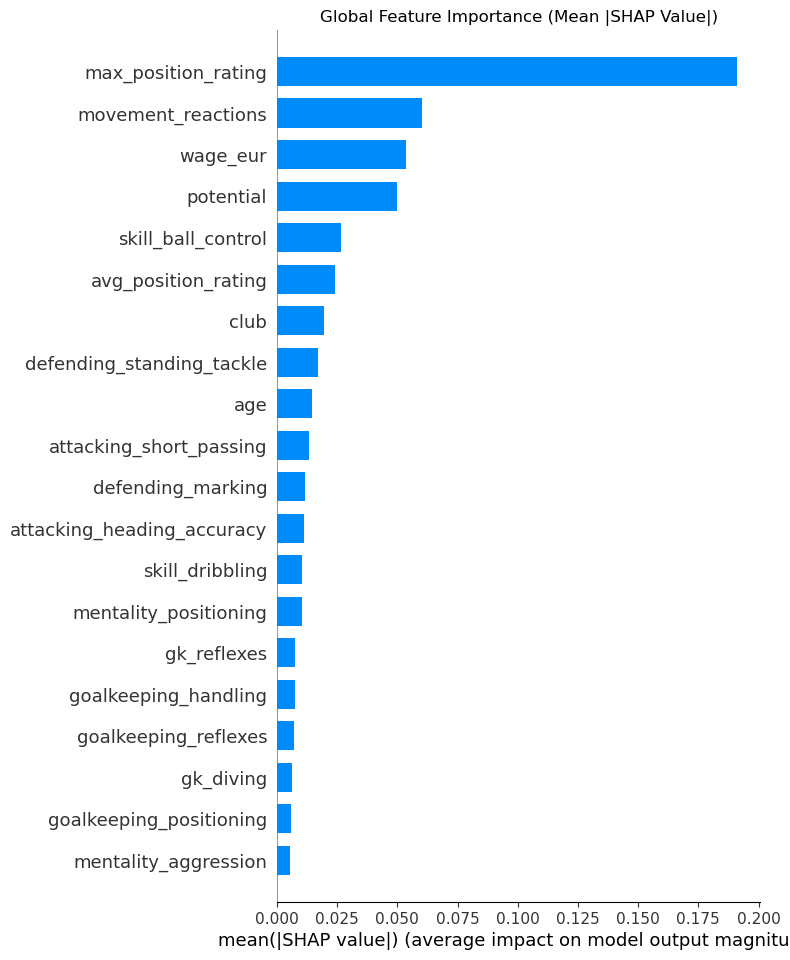

In [46]:
from sklearn.ensemble import RandomForestClassifier

refined_rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
refined_rf.fit(X_train_refined[best_features_list], y_train_refined)

print("Calculating SHAP values... (this may take a minute)")

X_test_subset = X_test[best_features_list]

explainer = shap.TreeExplainer(refined_rf)
shap_values = explainer.shap_values(X_test_subset)

if isinstance(shap_values, list):
    target_shap = shap_values[1] 
else:
   
    target_shap = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(target_shap, X_test_subset, plot_type="bar", show=False)
plt.title("Global Feature Importance (Mean |SHAP Value|)")
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.savefig('shap_feature_importance_bar.png', bbox_inches='tight')
plt.show()

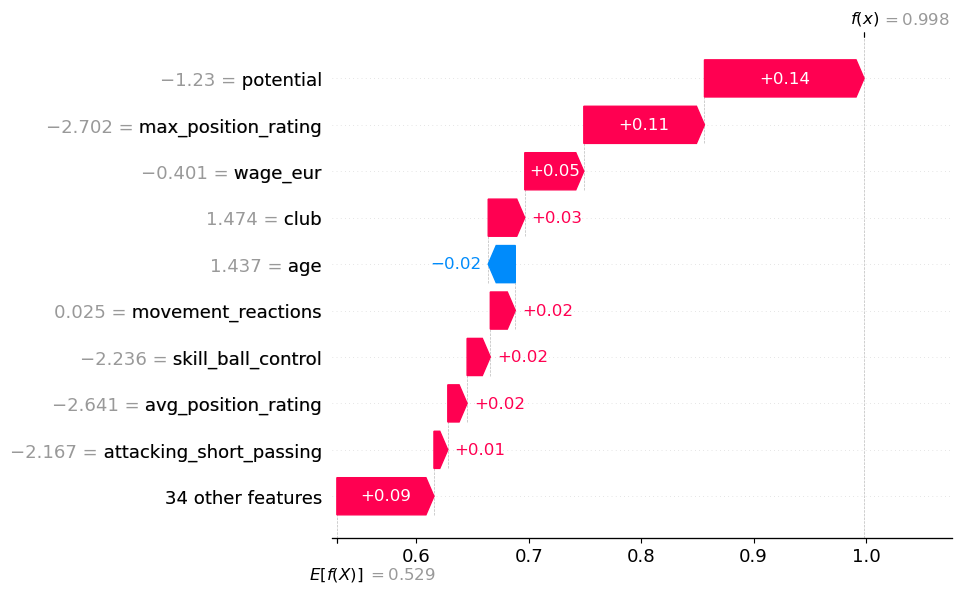

In [47]:
try:
    if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1:
        base_val = explainer.expected_value[1]
    else:
        base_val = explainer.expected_value

    plt.figure()
    exp = shap.Explanation(values=target_shap[0],
                           base_values=base_val,
                           data=X_test_subset.iloc[0],
                           feature_names=X_test_subset.columns)
    shap.plots.waterfall(exp, show=False)
    plt.savefig('shap_waterfall.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Waterfall plot failed: {e}")

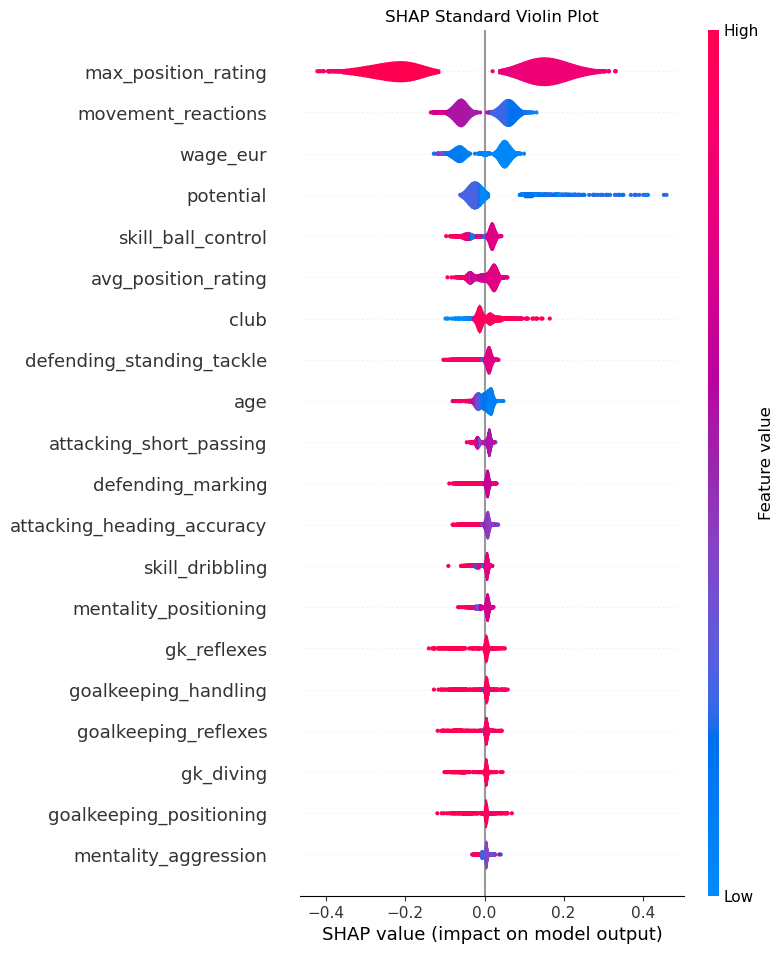

In [48]:
plt.figure()
shap.summary_plot(target_shap, X_test_subset, plot_type="violin", show=False)
plt.title("SHAP Standard Violin Plot")
plt.savefig('shap_violin_standard.png', bbox_inches='tight')
plt.show()